## Load and demonstrate Dataset

In [4]:
import numpy as np

ground_truth = np.load('ellipses.npy'); support = ground_truth>0 #Extract the support area
ellipse_sampling = np.load('ellipses_sampling.npy')
for i in range(len(ellipse_sampling)):
    ellipse_sampling[i] /= ellipse_sampling[i].max()

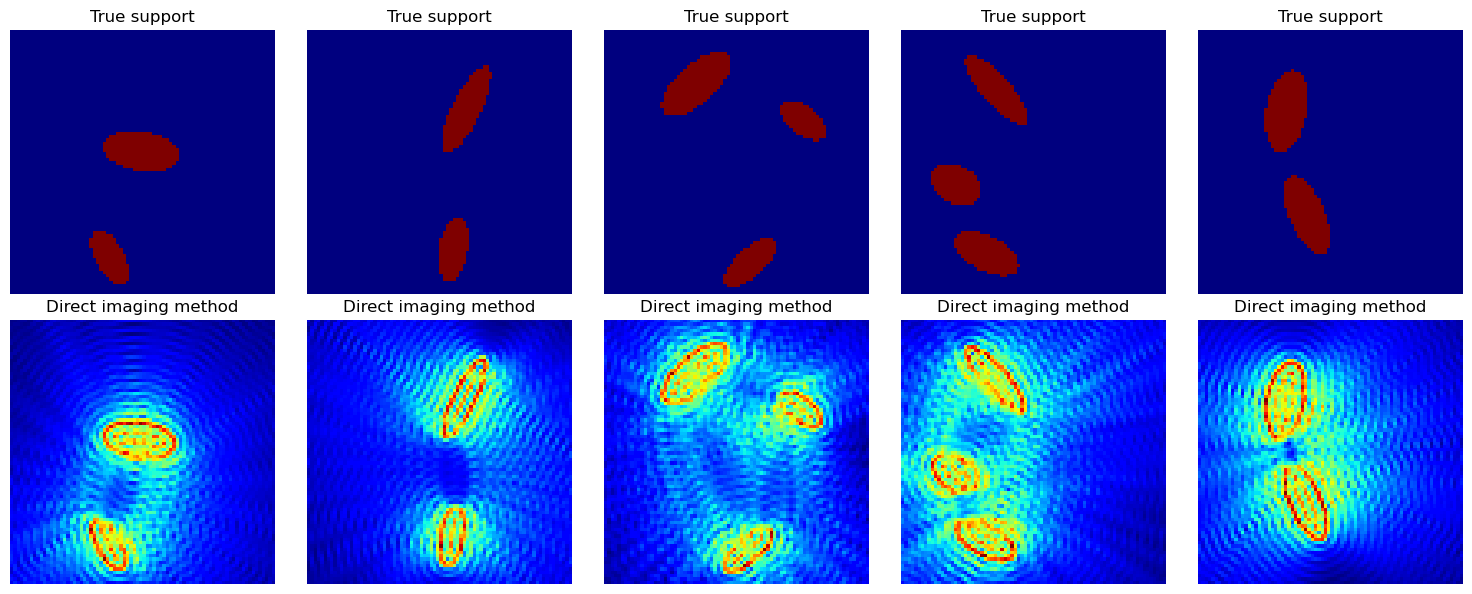

In [5]:
import matplotlib.pyplot as plt

# Illustration of the dataset
num_samples = 5
fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

for i in range(num_samples):
    ax_top = axes[0, i]
    im_top = ax_top.imshow(support[i], cmap='jet')
    ax_top.set_title(f'True support')
    ax_top.axis('off')
    ax_bottom = axes[1, i]
    im_bottom = ax_bottom.imshow(ellipse_sampling[i], cmap='jet')
    ax_bottom.set_title(f'Direct imaging method')
    ax_bottom.axis('off')
plt.tight_layout()
plt.savefig('Training_Samples.jpg')
plt.show()

In [5]:
import torch
from torch.autograd import Variable
from torch.utils.data import TensorDataset

# Define the training dataset and validation dataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def array_to_tensor(array, device = device):
  array = torch.from_numpy(array)
  array = torch.unsqueeze(array, dim=1).float()
  array = Variable(array)
  tensor = array.to(device)
  return tensor

x_train = array_to_tensor(ellipse_sampling[:1800]); y_train = array_to_tensor(support[:1800])
x_valid = array_to_tensor(ellipse_sampling[1800:]); y_valid = array_to_tensor(support[1800:])
train_dataset = TensorDataset(x_train, y_train)
valid_dataset = TensorDataset(x_valid, y_valid)

## Load and train the U-Net

In [ ]:
import torch
from U_net import unet
import torch.utils.data as Data

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# Fix the stochastic seed
set_seed(0)

net = unet(feature_scale=4)
net.to(device)

# Print the number of training parameters
total_trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f'There are total {total_trainable_params:,} training parameters.')

# Define the loss function
loss_func = torch.nn.MSELoss()

# Define hyper-parameters for the optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
train_loader = Data.DataLoader(dataset = train_dataset, batch_size = 10, shuffle = True)
valid_loader = Data.DataLoader(dataset = valid_dataset, batch_size = 10)
EPOCH = 100
train_loss = []; valid_loss = []
for epoch in range(EPOCH):
    total_train = 0; count = 0
    net.train()
    for step, (x, y) in enumerate(train_loader):
        x = x.float(); y = y.float()
        output = net(x)
        loss = loss_func(output, y); total_train += loss.item(); count += 1
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    total_train /= count
    train_loss.append(total_train)
    total_valid = 0
    count = 0
    if epoch%1 == 0:
      net.eval()
      for step_, (valid_x, valid_y) in enumerate(valid_loader):
        with torch.no_grad():
          valid_output = net(valid_x)
        total_valid += loss_func(valid_output, valid_y).item()
        count += 1
      total_valid /= count
      valid_loss.append(total_valid)
      print('Epoch: ',epoch,'| train loss: %f'% total_train,'| valid loss: %f'%(total_valid))
      torch.save(net.state_dict(), 'support_Net.pth')

## Validate the training performance

In [ ]:
import torch
from U_net import unet
import numpy as np
import matplotlib.pyplot as plt

def support_Net(input_data):
    net = unet(feature_scale=4)
    net.load_state_dict(torch.load('support_Net.pth', weights_only=True))
    input_data = torch.from_numpy(input_data)
    input_data = torch.unsqueeze(input_data, dim=0).float()
    input_data = torch.unsqueeze(input_data, dim=0).float()
    output_data = net(input_data)
    output_data = output_data.data.numpy()
    return output_data[0][0]

ground_truth = np.load('ellipses.npy'); support = ground_truth>0 #Extract the support area
ellipse_sampling = np.load('ellipses_sampling.npy')
# Compute the normalization of the direct imaging method
for i in range(len(ellipse_sampling)):
    ellipse_sampling[i] /= ellipse_sampling[i].max()



start_idx = 1800
num_samples = 5
fig, axes = plt.subplots(3, num_samples, figsize=(15, 9))

for j, i in enumerate(range(start_idx, start_idx + num_samples)):
    
    ax_top = axes[0, j]
    im_top = ax_top.imshow(support[i], cmap='jet')
    ax_top.set_title(f'True support')       
    ax_top.axis('off')


    ax_mid = axes[1, j]
    im_mid = ax_mid.imshow(support_Net(ellipse_sampling[i]), cmap='jet')
    ax_mid.set_title(f'Prediction by support_Net')
    ax_mid.axis('off')


    ax_bottom = axes[2, j]
    im_bottom = ax_bottom.imshow(ellipse_sampling[i], cmap='jet')
    ax_bottom.set_title(f'Direct sampling method')
    ax_bottom.axis('off')

plt.tight_layout()
plt.savefig('Training_Performance.jpg')
plt.show()